# EduPredict
## Student Performance Prediction Using Linear Regression

**Course:** Machine Learning (AAT)

**Problem:** Predict a student's final examination marks using study hours, attendance percentage, and previous marks.

**Algorithm used:** Linear Regression (scikit-learn LinearRegression)

## 1. Introduction

Machine Learning is a branch of Artificial Intelligence that allows computers to learn patterns from data and make predictions without being explicitly programmed. This project falls under **supervised learning**, because we train the model on historical records where the answer (final marks) is already known.

Since we are predicting a continuous numeric value (marks), the specific type of supervised learning is called **regression**. We use **Linear Regression**, one of the simplest and most interpretable regression algorithms.

The goal is to build a model that estimates a student's final exam marks from three inputs: study hours per day, attendance percentage, and previous/internal marks.

## 2. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 3. Load Dataset

In [2]:
DATA = r'..\dataset\student_performance.csv'
FIG = r'..\results\figures'
os.makedirs(FIG, exist_ok=True)
os.makedirs(r'..\results\metrics', exist_ok=True)
os.makedirs(r'..\results\predictions', exist_ok=True)

df = pd.read_csv(DATA)
print('Dataset loaded successfully. Shape:', df.shape)

Dataset loaded successfully. Shape: (200, 4)


## 4. Dataset Overview

In [3]:
print('First 5 rows:')
display(df.head())
print('Last 5 rows:')
display(df.tail())

First 5 rows:


,Study_Hours,Attendance_Percentage,Previous_Marks,Final_Marks
0,8.0,88.9,49.6,63.6
1,4.9,98.6,89.7,70.4
2,8.7,75.0,80.8,68.8
3,7.3,57.2,37.2,30.0
4,1.8,50.7,94.8,51.2


Last 5 rows:


,Study_Hours,Attendance_Percentage,Previous_Marks,Final_Marks
195,2.6,72.7,48.1,46.3
196,6.4,91.3,75.7,75.0
197,8.9,64.8,71.2,59.6
198,2.8,72.9,93.8,66.8
199,3.8,72.1,70.3,48.0


In [4]:
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
print('Column names:', list(df.columns))
print('\nData types:')
print(df.dtypes)
print('\nDescriptive statistics:')
display(df.describe().round(2))

Number of rows: 200
Number of columns: 4
Column names: ['Study_Hours', 'Attendance_Percentage', 'Previous_Marks', 'Final_Marks']

Data types:
Study_Hours              float64
Attendance_Percentage    float64
Previous_Marks           float64
Final_Marks              float64
dtype: object

Descriptive statistics:


,Study_Hours,Attendance_Percentage,Previous_Marks,Final_Marks
count,200.00,200.00,200.00,200.00
mean,5.44,74.96,62.17,54.02
std,2.54,14.42,19.00,12.15
min,1.10,50.60,30.40,30.00
25%,3.28,61.80,45.00,45.00
50%,5.30,75.25,62.80,53.90
75%,7.70,88.32,78.32,64.15
max,9.90,99.30,94.90,85.80


## 5. Data Cleaning

We check for missing values, duplicate records, and invalid entries before training.

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())

before = len(df)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Rows before cleaning: {before}, rows after cleaning: {len(df)}')
print('Data cleaning done. The dataset is ready for EDA.')

Missing values per column:
Study_Hours              0
Attendance_Percentage    0
Previous_Marks           0
Final_Marks              0
dtype: int64
Duplicate rows: 0
Rows before cleaning: 200, rows after cleaning: 200
Data cleaning done. The dataset is ready for EDA.


## 6. Exploratory Data Analysis (EDA)

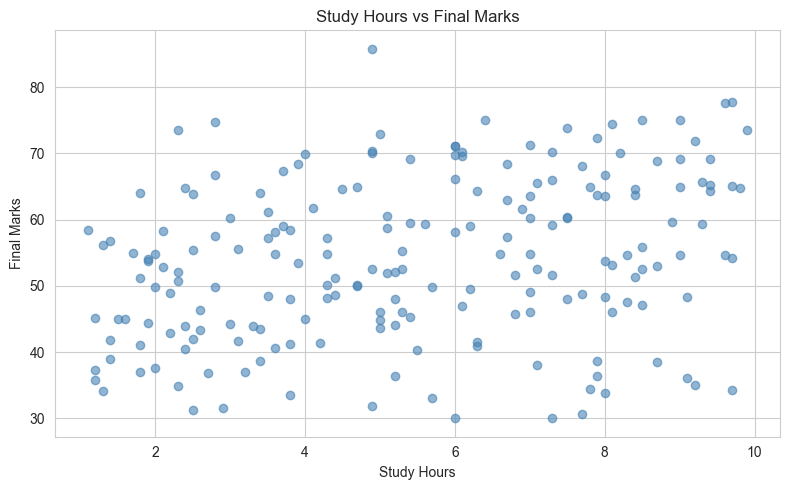

In [6]:
plt.scatter(df['Study_Hours'], df['Final_Marks'], alpha=0.6, color='steelblue')
plt.title('Study Hours vs Final Marks')
plt.xlabel('Study Hours'); plt.ylabel('Final Marks')
plt.tight_layout(); plt.show()

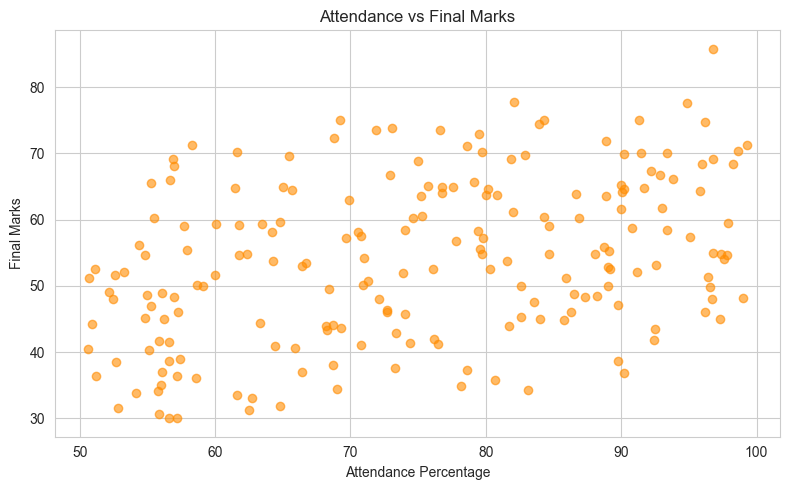

In [7]:
plt.scatter(df['Attendance_Percentage'], df['Final_Marks'], alpha=0.6, color='darkorange')
plt.title('Attendance vs Final Marks')
plt.xlabel('Attendance Percentage'); plt.ylabel('Final Marks')
plt.tight_layout(); plt.show()

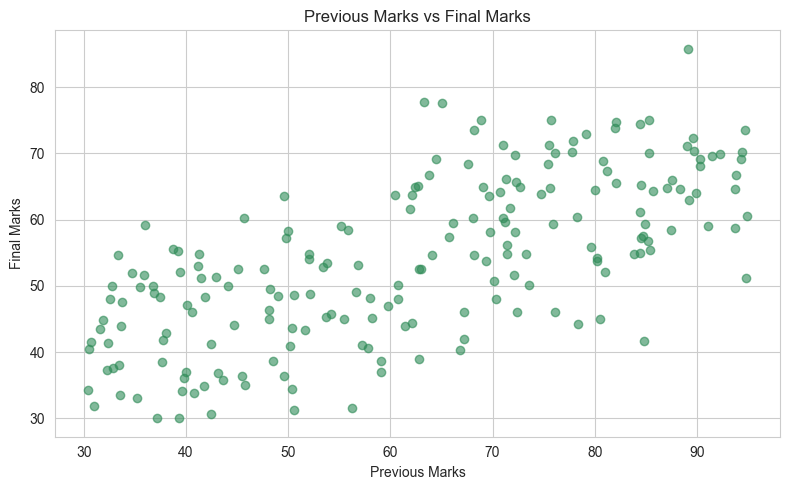

In [8]:
plt.scatter(df['Previous_Marks'], df['Final_Marks'], alpha=0.6, color='seagreen')
plt.title('Previous Marks vs Final Marks')
plt.xlabel('Previous Marks'); plt.ylabel('Final Marks')
plt.tight_layout(); plt.show()

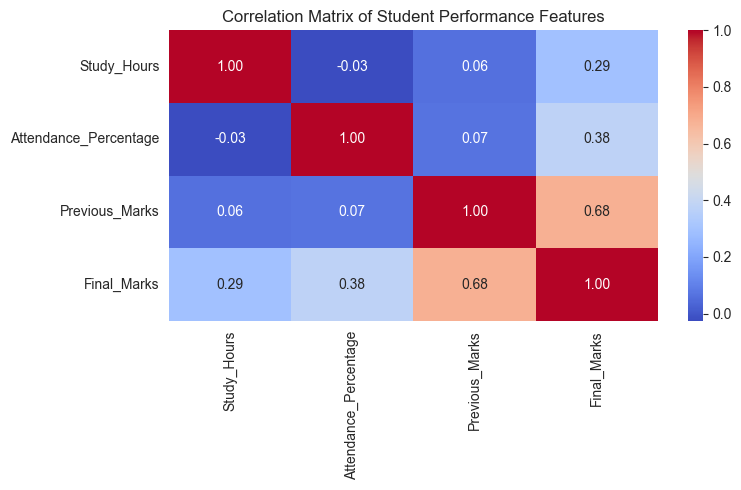

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Student Performance Features')
plt.tight_layout(); plt.show()

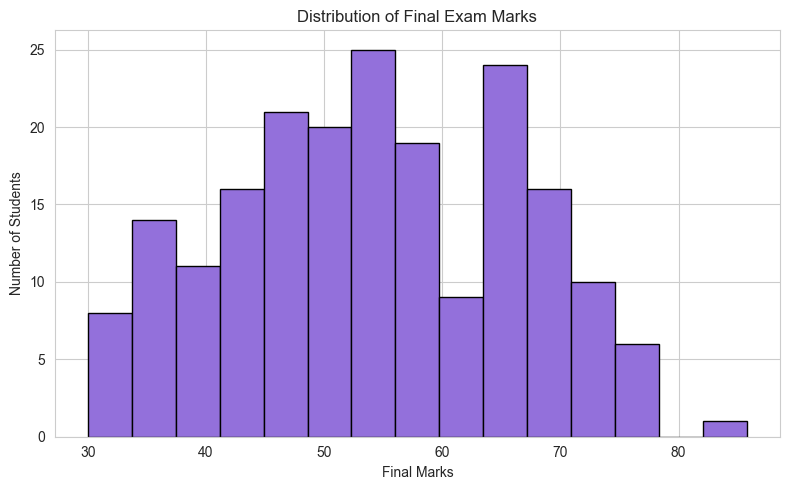

In [10]:
plt.hist(df['Final_Marks'], bins=15, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Final Exam Marks')
plt.xlabel('Final Marks'); plt.ylabel('Number of Students')
plt.tight_layout(); plt.show()

## 7. Feature and Target Selection

Independent variables (features X): Study Hours, Attendance Percentage, Previous Marks

Dependent variable (target y): Final Marks

In [11]:
X = df[['Study_Hours', 'Attendance_Percentage', 'Previous_Marks']]
y = df['Final_Marks']
print('Features (X):', list(X.columns))
print('Target (y): Final_Marks')
print('X shape:', X.shape, '| y shape:', y.shape)

Features (X): ['Study_Hours', 'Attendance_Percentage', 'Previous_Marks']
Target (y): Final_Marks
X shape: (200, 3) | y shape: (200,)


## 8. Train-Test Split

We split the data into 80% training and 20% testing. `random_state = 42` is used so the split is the same every time we run the project. A train-test split is used to evaluate the model on data it has never seen, which gives an honest estimate of real-world performance.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 160
Testing samples : 40


## 9. Linear Regression Model

Linear Regression fits a straight-line relationship between the inputs and the output:

```
Final_Marks = b0 + b1*(Study_Hours) + b2*(Attendance) + b3*(Previous_Marks)
```

- b0 is the intercept (predicted marks when all features are 0)
- b1, b2, b3 are the coefficients, telling how much Final_Marks changes when that feature increases by 1 unit, keeping the other features constant.

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

## 10. Model Training

In [14]:
model.fit(X_train, y_train)
print('Model trained successfully on the training data.')

Model trained successfully on the training data.


## 11. Predictions

In [15]:
y_pred = model.predict(X_test)
results = pd.DataFrame({
    'Actual_Final_Marks': y_test.values,
    'Predicted_Final_Marks': np.round(y_pred, 2),
    'Prediction_Error': np.round(y_test.values - y_pred, 2)
})
display(results.head(10))
results.to_csv(r'..\results\predictions\test_predictions.csv', index=False)
print('Predictions saved to results/predictions/test_predictions.csv')

,Actual_Final_Marks,Predicted_Final_Marks,Prediction_Error
0,57.4,62.79,-5.39
1,60.2,47.84,12.36
2,68.1,62.58,5.52
3,60.3,58.56,1.74
4,53.7,59.05,-5.35
5,53.0,46.52,6.48
6,52.6,46.39,6.21
7,54.8,51.47,3.33
8,55.4,54.77,0.63
9,70.1,68.29,1.81


Predictions saved to results/predictions/test_predictions.csv


## 12. Model Evaluation

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE) : {mae:.4f}')
print(f'Mean Squared Error (MSE)  : {mse:.4f}')
print(f'Root Mean Sq Error (RMSE) : {rmse:.4f}')
print(f'R2 Score                  : {r2:.4f}')

with open(r'..\results\metrics\model_metrics.txt', 'w') as f:
    f.write('Student Performance Prediction - Model Evaluation Metrics\n')
    f.write('============================================================\n')
    f.write(f'Mean Absolute Error (MAE) : {mae:.4f}\n')
    f.write(f'Mean Squared Error (MSE)  : {mse:.4f}\n')
    f.write(f'Root Mean Squared Error   : {rmse:.4f}\n')
    f.write(f'R2 Score                  : {r2:.4f}\n')
print('Metrics saved to results/metrics/model_metrics.txt')

Mean Absolute Error (MAE) : 5.6561
Mean Squared Error (MSE)  : 47.1436
Root Mean Sq Error (RMSE) : 6.8661
R2 Score                  : 0.6206
Metrics saved to results/metrics/model_metrics.txt


## 13. Model Coefficients

In [17]:
print(f'Intercept (b0): {model.intercept_:.4f}')
for name, coef in zip(X.columns, model.coef_):
    print(f'Coefficient of {name}: {coef:.4f}')

print('\nInterpretation: a positive coefficient means that, keeping the other features constant, an increase in that feature increases the predicted final marks.')

Intercept (b0): -0.3966
Coefficient of Study_Hours: 1.1695
Coefficient of Attendance_Percentage: 0.3000
Coefficient of Previous_Marks: 0.4084

Interpretation: a positive coefficient means that, keeping the other features constant, an increase in that feature increases the predicted final marks.


## 14. Visualizations

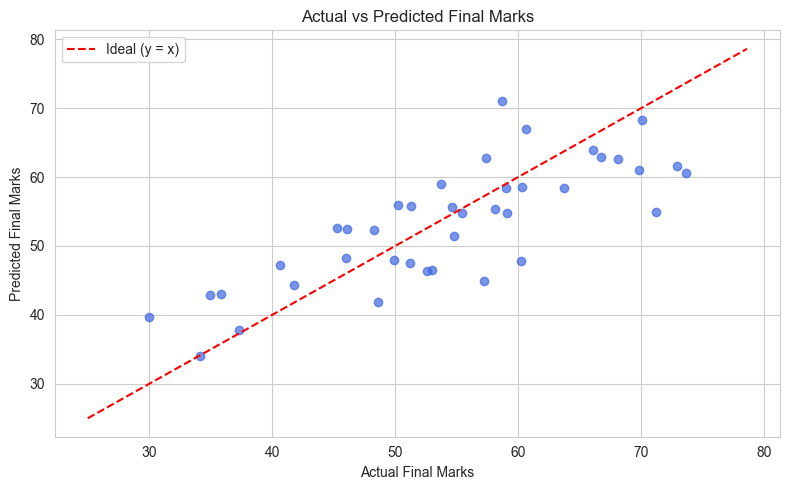

In [18]:
plt.scatter(y_test, y_pred, alpha=0.7, color='royalblue')
lims = [min(y_test.min(), y_pred.min()) - 5, max(y_test.max(), y_pred.max()) + 5]
plt.plot(lims, lims, 'r--', label='Ideal (y = x)')
plt.title('Actual vs Predicted Final Marks')
plt.xlabel('Actual Final Marks'); plt.ylabel('Predicted Final Marks')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG, 'actual_vs_predicted.png'), dpi=150)
plt.show()

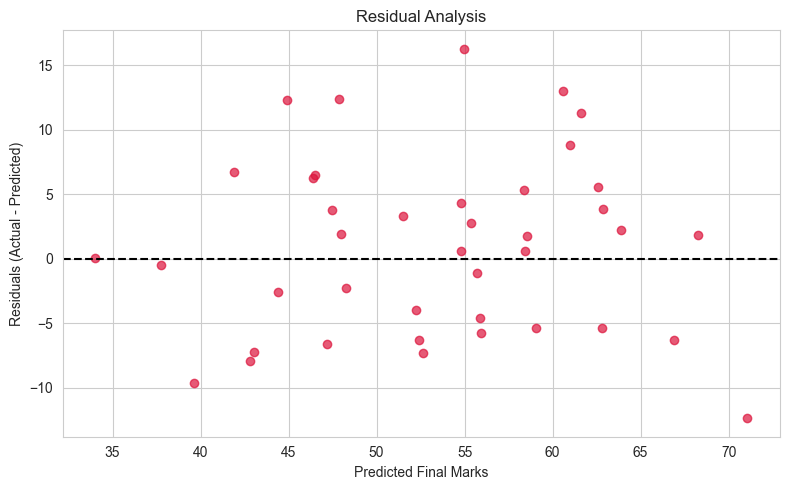

In [19]:
residuals = y_test.values - y_pred
plt.scatter(y_pred, residuals, alpha=0.7, color='crimson')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Analysis')
plt.xlabel('Predicted Final Marks'); plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'residual_plot.png'), dpi=150)
plt.show()

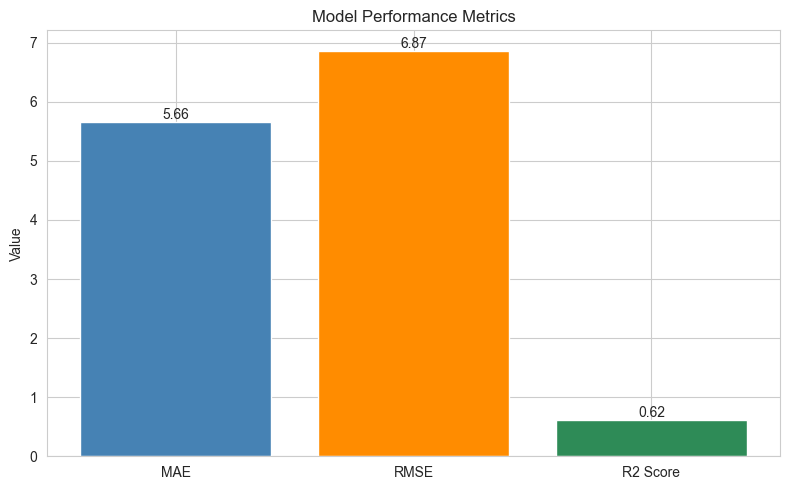

In [20]:
bars = plt.bar(['MAE', 'RMSE', 'R2 Score'], [mae, rmse, r2],
               color=['steelblue', 'darkorange', 'seagreen'])
for bar, val in zip(bars, [mae, rmse, r2]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}', ha='center', va='bottom')
plt.title('Model Performance Metrics'); plt.ylabel('Value')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'model_metrics.png'), dpi=150)
plt.show()

## 15. Sample Prediction

In [21]:
def predict_marks(study_hours, attendance, previous_marks):
    sample = pd.DataFrame(
        [[study_hours, attendance, previous_marks]],
        columns=['Study_Hours', 'Attendance_Percentage', 'Previous_Marks']
    )
    return float(model.predict(sample)[0])

study_hours = 6
attendance = 85
previous_marks = 70
result = predict_marks(study_hours, attendance, previous_marks)
print(f'Study Hours = {study_hours}')
print(f'Attendance = {attendance}')
print(f'Previous Marks = {previous_marks}')
print(f'Predicted Final Marks = {result:.2f}')

Study Hours = 6
Attendance = 85
Previous Marks = 70
Predicted Final Marks = 60.70


## 16. Results

The trained model achieved:

| Metric | Value |
|--------|-------|
| MAE | 5.66 |
| MSE | 47.14 |
| RMSE | 6.87 |
| R2 Score | 0.62 |

An R2 of about 0.62 means the three features together explain roughly 62% of the variation in final marks. The remaining variation is due to factors not present in the dataset, such as study quality, health, and stress.

## 17. Conclusion

This project used Linear Regression to predict final exam marks from study hours, attendance, and previous marks. All three coefficients came out positive, matching the intuition that more study, better attendance, and stronger previous performance are associated with higher final marks. The model is simple, easy to interpret, and gives a reasonably useful prediction, though it cannot capture every real-world factor affecting student performance. Limitations include the small dataset, only three input features, and the assumption of a linear relationship.